# 🏥 Taller: Segmentación Inteligente de Servicios Clínicos con PCA + K-Means

**Doctorado en Ciencia de Datos e Inteligencia Artificial — Universidad El Bosque**

Este notebook desarrolla, paso a paso, un pipeline de **Machine Learning no supervisado** aplicado a datos clínicos almacenados en una base de datos relacional MySQL.

---

## 🎯 ¿Qué vamos a aprender?

Al finalizar este taller podremos:

1. Conectarnos desde Python a una base de datos **MySQL**.
2. Consultar varias tablas mediante `JOIN`.
3. Explorar y comprender un conjunto de datos clínicos.
4. Identificar valores faltantes, duplicados y posibles outliers.
5. Entender **por qué debemos escalar** antes de PCA y K-Means.
6. Aplicar **PCA** y analizar:
   - varianza explicada;
   - varianza acumulada;
   - número de componentes necesario para conservar al menos 80 %;
   - *loadings* o contribución de las variables.
7. Aplicar **K-Means** y seleccionar un número razonable de clústeres.
8. Interpretar los clústeres en las unidades originales.
9. Determinar qué especialidades médicas predominan en cada grupo.
10. Comparar qué ocurre **con y sin escalado**.
11. Reflexionar sobre las implicaciones éticas de usar segmentación en salud.
12. Preparar resultados para el informe final.

> **Idea central:** PCA no “crea grupos”. PCA resume la información.  
> **K-Means sí busca grupos** de observaciones parecidas.

## 1. Contexto del problema

La clínica del caso de estudio posee información distribuida en cuatro tablas:

- `medicos`
- `pacientes`
- `citas`
- `tratamientos`

Para cada cita analizaremos principalmente seis variables numéricas:

| Variable | Significado |
|---|---|
| `edad` | Edad del paciente |
| `duracion_min` | Duración de la consulta en minutos |
| `costo_cita` | Costo de la cita |
| `dosis_mg` | Dosis del medicamento |
| `dias_tratamiento` | Duración del tratamiento |
| `satisfaccion` | Calificación de satisfacción |

También utilizaremos la variable categórica `especialidad` para **interpretar** los clústeres después del modelado.

### Pregunta de negocio

> ¿Existen grupos naturales de citas con características semejantes que puedan ayudar a comprender mejor el comportamiento de los servicios clínicos?

⚠️ Los clústeres son una herramienta **descriptiva/exploratoria**. No deben interpretarse automáticamente como categorías diagnósticas, niveles de riesgo o decisiones clínicas.

# 2. Preparación del entorno

En Google Colab algunas librerías necesarias para conectarnos a MySQL pueden no estar instaladas.

La instrucción `%pip install` instala las dependencias solamente en la sesión actual de Colab.

In [ ]:
%pip -q install mysql-connector-python sqlalchemy pymysql kneed

## 2.1. Importar librerías

Usaremos:

- `pandas`: manipulación de datos.
- `numpy`: operaciones numéricas.
- `matplotlib` y `seaborn`: gráficas.
- `sqlalchemy`: conexión segura y cómoda con MySQL.
- `sklearn`: escalado, PCA, K-Means y métricas.
- `kneed`: ayuda a localizar automáticamente el “codo”.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

from kneed import KneeLocator
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_context("notebook")

# 3. Conexión a MySQL


In [ ]:
!pip install pymysql

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Conectar las bases de datos

In [ ]:
import pandas as pd

from sqlalchemy import create_engine, URL

# Datos del servidor remoto
usuario   = "uokplago_doctorado2"
password  = "Doctorado2026%$"  # Ya no importan @, # o :
host      = "cdtiueb.com.co"
puerto    = 3306
basedatos = "uokplago_clinica_ml"

# ✅ Construcción segura
url = URL.create(
    drivername="mysql+pymysql",
    username=usuario,
    password=password,
    host=host,
    port=puerto,
    database=basedatos,
)

engine = create_engine(url)

## Motor, es crear la url

In [ ]:
engine = create_engine(url)

In [ ]:
# Consulta SQL
query = """
SELECT
    m.especialidad AS especialidad,
    p.edad AS edad,
    c.duracion_min AS duracion_min,
    c.costo AS costo_cita,
    t.dosis_mg AS dosis_mg,
    t.dias_tratamiento AS dias_tratamiento,
    c.satisfaccion AS satisfaccion
FROM citas c
JOIN pacientes p
    ON p.id_paciente = c.id_paciente
JOIN medicos m
    ON m.id_medico = c.id_medico
JOIN tratamientos t
    ON t.id_cita = c.id_cita
ORDER BY c.id_cita;
"""

# Ejecutar consulta
df = pd.read_sql(query, con=engine)

df


,especialidad,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion
0,Cardiología,34,45,"250,000.0000",50.0000,30,5
1,Ortopedia,45,30,"180,000.0000",400.0000,10,4
2,Dermatología,28,25,"150,000.0000",20.0000,15,5
3,Neurología,52,60,"320,000.0000",50.0000,20,3
4,Pediatría,19,20,"120,000.0000",0.5000,1,5
...,...,...,...,...,...,...,...
195,Pediatría,41,20,"120,000.0000",160.0000,3,5
196,Dermatología,37,30,"180,000.0000",20.0000,90,4
197,Neurología,52,55,"310,000.0000",25.0000,60,3
198,Ortopedia,30,40,"250,000.0000",100.0000,15,4


# 4. Verificar que el usuario sea de solo consulta

El enunciado indica que la cuenta entregada debe tener privilegios únicamente para realizar consultas.

En lugar de probar un `INSERT`, `UPDATE` o `DELETE`, consultaremos los privilegios mediante:

```sql
SHOW GRANTS FOR CURRENT_USER;
```

### ¿Qué esperamos encontrar?

Idealmente permisos relacionados con lectura, por ejemplo `SELECT`.

No deberíamos encontrar privilegios de modificación como `INSERT`, `UPDATE`, `DELETE`, `DROP` o `ALTER`.

In [ ]:
with engine.connect() as conn:
    grants = pd.read_sql(
        text("SHOW GRANTS FOR CURRENT_USER;"),
        conn
    )

display(grants)

texto_grants = " ".join(
    grants.astype(str).values.flatten()
).upper()

privilegios_escritura = [
    "INSERT",
    "UPDATE",
    "DELETE",
    "DROP",
    "ALTER"
]

encontrados = [
    permiso
    for permiso in privilegios_escritura
    if permiso in texto_grants
]

if encontrados:
    print("⚠️ Revisar: se detectaron palabras asociadas a permisos de escritura:")
    print(encontrados)
else:
    print("✅ No se detectaron privilegios de escritura comunes en SHOW GRANTS.")
    print("La cuenta parece apropiada para un ejercicio de solo lectura.")

,Grants for uokplago_doctorado2@%
0,GRANT USAGE ON *.* TO `uokplago_doctorado2`@`%`
1,GRANT SELECT ON `uokplago\_clinica\_ml`.* TO `...


✅ No se detectaron privilegios de escritura comunes en SHOW GRANTS.
La cuenta parece apropiada para un ejercicio de solo lectura.


Con el código anterior se puede observar que realmente el usuario solamente puede realizar consultas y no permite realizar **`inserción`**, **`borrado`** o que permita modificar la base de datos.

# 5. Explorar la estructura de la base de datos

Antes de hacer Machine Learning debemos conocer las tablas disponibles.

> **Machine Learning comienza entendiendo los datos, no entrenando modelos.**

In [ ]:
with engine.connect() as conn:
    tablas = pd.read_sql(
        text("SHOW TABLES;"),
        conn
    )

display(tablas)

,Tables_in_uokplago_clinica_ml
0,citas
1,medicos
2,pacientes
3,tratamientos


La base de datos relacionada cuenta con 4 bases de las cuales son **`citas`**, **`medicos`**, **`pacientes`** y por última **`tratamientos`**.

## 5.1. Mostrar una muestra de cada tabla

Esto responde al entregable que solicita una muestra de cada tabla de la base de datos.

Usaremos `LIMIT 5` para no descargar más información de la necesaria.

In [ ]:
tablas_taller = [
    "medicos",
    "pacientes",
    "citas",
    "tratamientos"
]

for tabla in tablas_taller:
    print("\n" + "=" * 90)
    print(f"TABLA: {tabla.upper()}")
    print("=" * 90)

    consulta = text(f"SELECT * FROM {tabla} LIMIT 5;")

    with engine.connect() as conn:
        muestra = pd.read_sql(
            consulta,
            conn
        )

    display(muestra)


TABLA: MEDICOS


,id_medico,nombre,especialidad,anios_experiencia,salario_mensual,ciudad
0,1,Dr. Andrés Ramírez,Cardiología,15,"8,500,000.0000",Bogotá
1,2,Dra. Luisa Gómez,Pediatría,9,"6,200,000.0000",Medellín
2,3,Dr. Carlos Pérez,Dermatología,12,"7,100,000.0000",Cali
3,4,Dra. María Restrepo,Neurología,20,"9,800,000.0000",Bogotá
4,5,Dr. Juan Torres,Ortopedia,6,"5,400,000.0000",Barranquilla



TABLA: PACIENTES


,id_paciente,nombre,edad,genero,peso_kg,altura_m,ciudad,fecha_registro
0,1,Ana María López,34,F,62.5000,1.6500,Bogotá,2023-01-15
1,2,Pedro Sánchez,45,M,82.0000,1.7800,Medellín,2023-02-10
2,3,Lucía Gómez,28,F,55.0000,1.6000,Cali,2023-03-05
3,4,Jorge Ramírez,52,M,90.5000,1.7500,Bogotá,2023-03-22
4,5,Camila Torres,19,F,50.0000,1.5800,Barranquilla,2023-04-01



TABLA: CITAS


,id_cita,id_paciente,id_medico,fecha_cita,duracion_min,costo,diagnostico,satisfaccion,asistio
0,1,1,1,2024-01-05,45,"250,000.0000",Hipertensión,5,1
1,2,2,5,2024-01-07,30,"180,000.0000",Lumbalgia,4,1
2,3,3,3,2024-01-09,25,"150,000.0000",Dermatitis,5,1
3,4,4,4,2024-01-11,60,"320,000.0000",Migraña crónica,3,1
4,5,5,2,2024-01-13,20,"120,000.0000",Vacunación,5,1



TABLA: TRATAMIENTOS


,id_tratamiento,id_cita,medicamento,dosis_mg,dias_tratamiento,costo_tratamiento
0,1,1,Losartán,50.0000,30,"80,000.0000"
1,2,2,Ibuprofeno,400.0000,10,"25,000.0000"
2,3,3,Hidrocortisona,20.0000,15,"45,000.0000"
3,4,4,Sumatriptán,50.0000,20,"120,000.0000"
4,5,5,Vacuna Triple,0.5000,1,"60,000.0000"


## 5.2. Script SQL equivalente

El siguiente bloque puede copiarse a un archivo `.sql` como parte del entregable:

```sql
USE uokplago_clinica_ml;

SELECT * FROM medicos LIMIT 5;
SELECT * FROM pacientes LIMIT 5;
SELECT * FROM citas LIMIT 5;
SELECT * FROM tratamientos LIMIT 5;
```

# 6. Construcción del dataset analítico con `JOIN`

Los datos necesarios están distribuidos en varias tablas, por lo que debemos hacer un `JOIN`.

### ¿Qué hace un JOIN?

Un `JOIN` combina información de tablas relacionadas mediante llaves:

- `citas.id_paciente` permite encontrar al paciente.
- `citas.id_medico` permite encontrar al médico.
- `tratamientos.id_cita` permite encontrar el tratamiento asociado.

### Extensión técnica

Incluimos también `c.id_cita`.

No será utilizado como variable de Machine Learning; funcionará únicamente como identificador para conservar la trazabilidad de cada fila.

In [ ]:
consulta_analitica = """
SELECT
    c.id_cita AS id_cita,
    m.especialidad AS especialidad,
    p.edad AS edad,
    c.duracion_min AS duracion_min,
    c.costo AS costo_cita,
    t.dosis_mg AS dosis_mg,
    t.dias_tratamiento AS dias_tratamiento,
    c.satisfaccion AS satisfaccion
FROM citas c
JOIN pacientes p
    ON p.id_paciente = c.id_paciente
JOIN medicos m
    ON m.id_medico = c.id_medico
JOIN tratamientos t
    ON t.id_cita = c.id_cita
ORDER BY c.id_cita;
"""

with engine.connect() as conn:
    df = pd.read_sql(
        text(consulta_analitica),
        conn
    )

print("✅ Consulta ejecutada correctamente")
print("Dimensiones:", df.shape)

display(df.head())

✅ Consulta ejecutada correctamente
Dimensiones: (200, 8)


,id_cita,especialidad,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion
0,1,Cardiología,34,45,"250,000.0000",50.0000,30,5
1,2,Ortopedia,45,30,"180,000.0000",400.0000,10,4
2,3,Dermatología,28,25,"150,000.0000",20.0000,15,5
3,4,Neurología,52,60,"320,000.0000",50.0000,20,3
4,5,Pediatría,19,20,"120,000.0000",0.5000,1,5


# 7. Comprensión inicial de los datos

Antes del modelado responderemos:

- ¿Cuántas filas tenemos?
- ¿Cuántas columnas?
- ¿Qué tipo de dato tiene cada variable?
- ¿Hay valores faltantes?
- ¿Hay filas duplicadas?
- ¿Los rangos parecen razonables?

Esta etapa corresponde a la **comprensión de los datos** dentro de CRISP-DM.

In [ ]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

print("\nColumnas:")
print(list(df.columns))

print("\nTipos de datos:")
display(
    pd.DataFrame({
        "columna": df.columns,
        "tipo": df.dtypes.astype(str).values
    })
)

Número de filas: 200
Número de columnas: 8

Columnas:
['id_cita', 'especialidad', 'edad', 'duracion_min', 'costo_cita', 'dosis_mg', 'dias_tratamiento', 'satisfaccion']

Tipos de datos:


,columna,tipo
0,id_cita,int64
1,especialidad,object
2,edad,int64
3,duracion_min,int64
4,costo_cita,float64
5,dosis_mg,float64
6,dias_tratamiento,int64
7,satisfaccion,int64


La base de datos final cuenta con 200 registros y 8 variables, las cuales son: `id_cita`, `especialidad`, `edad`, `duracion_min`, `costo_cita`, `dosis_mg`, `dias_tratamiento`, `satisfaccion`

## 7.1. Valores faltantes

Un valor faltante puede aparecer como `NaN`.

No debemos eliminar filas automáticamente. Primero debemos saber cuántos faltantes existen, en qué variables y qué porcentaje representan.

,faltantes,porcentaje_%
id_cita,0,0.0000
especialidad,0,0.0000
edad,0,0.0000
duracion_min,0,0.0000
costo_cita,0,0.0000
dosis_mg,0,0.0000
dias_tratamiento,0,0.0000
satisfaccion,0,0.0000


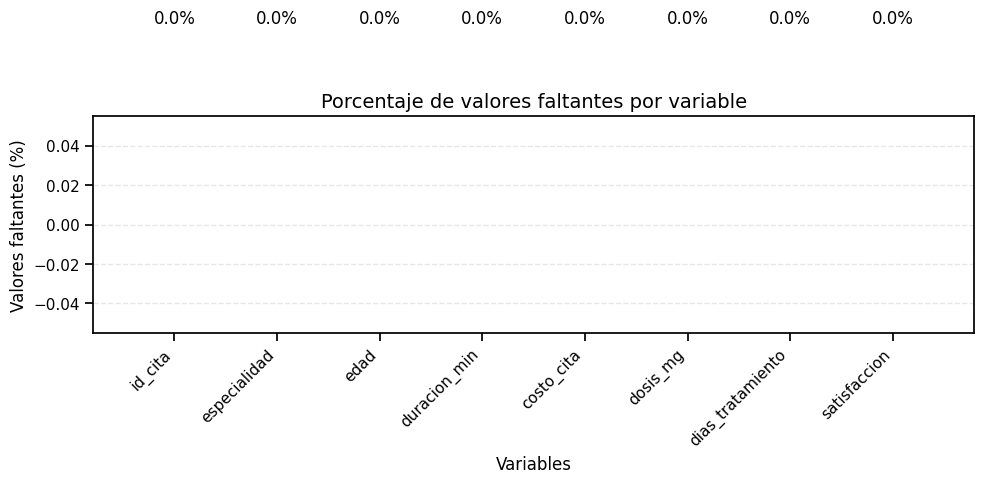

In [ ]:
# ============================================================
# ANÁLISIS DE VALORES FALTANTES
# ============================================================

faltantes = pd.DataFrame({

    "faltantes": df.isna().sum(),

    "porcentaje_%": df.isna().mean() * 100

}).sort_values(

    "faltantes",

    ascending=False

)

display(faltantes)


# ============================================================
# GRÁFICA DE VALORES FALTANTES
# ============================================================

import matplotlib.pyplot as plt

faltantes_grafica = faltantes.sort_values(
    "porcentaje_%",
    ascending=False
)

plt.figure(figsize=(10, 6))

barras = plt.bar(
    faltantes_grafica.index,
    faltantes_grafica["porcentaje_%"]
)

for barra, porcentaje in zip(
    barras,
    faltantes_grafica["porcentaje_%"]
):

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f"{porcentaje:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title(
    "Porcentaje de valores faltantes por variable",
    fontsize=14
)

plt.xlabel("Variables")
plt.ylabel("Valores faltantes (%)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

Se puede observar que la base de datos no cuenta con datos faltantes, es decir, que sus registros estan completos.

## 7.2. Duplicados

Un duplicado exacto puede indicar repetición accidental, duplicación durante una extracción o, en algunos contextos, dos registros legítimamente iguales. Primero los contamos.

In [ ]:
duplicados = df.duplicated().sum()

print("Número de filas duplicadas exactas:", duplicados)

Número de filas duplicadas exactas: 0


## 7.3. Estadísticas descriptivas

`describe()` resume media, desviación estándar, mínimo, cuartiles y máximo.

In [ ]:
variables_numericas = [
    "edad",
    "duracion_min",
    "costo_cita",
    "dosis_mg",
    "dias_tratamiento",
    "satisfaccion"
]

display(
    df[variables_numericas]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
edad,200.0000,39.0400,11.6515,19.0000,29.0000,38.0000,48.2500,61.0000
duracion_min,200.0000,38.7500,12.2551,20.0000,30.0000,37.5000,50.0000,60.0000
costo_cita,200.0000,"227,250.0000","71,121.2250","110,000.0000","177,500.0000","210,000.0000","300,000.0000","350,000.0000"
dosis_mg,200.0000,180.0525,188.4024,0.5000,20.0000,100.0000,325.0000,600.0000
dias_tratamiento,200.0000,37.6650,30.9920,1.0000,15.0000,30.0000,60.0000,120.0000
satisfaccion,200.0000,4.0900,0.7906,3.0000,3.0000,4.0000,5.0000,5.0000


El conjunto de datos contiene 200 citas con perfiles diversos en edad, duración, costo y tratamiento. Las variables con mayor variabilidad son el costo de la cita, la dosis del medicamento y los días de tratamiento, mientras que la satisfacción se concentra en valores altos.

# 8. Análisis exploratorio de datos — EDA

EDA significa **Exploratory Data Analysis**.

Su objetivo no es todavía crear el modelo, sino **entender cómo se comportan los datos**.

## 8.1. Histogramas

Un histograma muestra cómo se distribuyen los valores de una variable y permite observar concentración, asimetría, colas largas y posibles valores extremos.

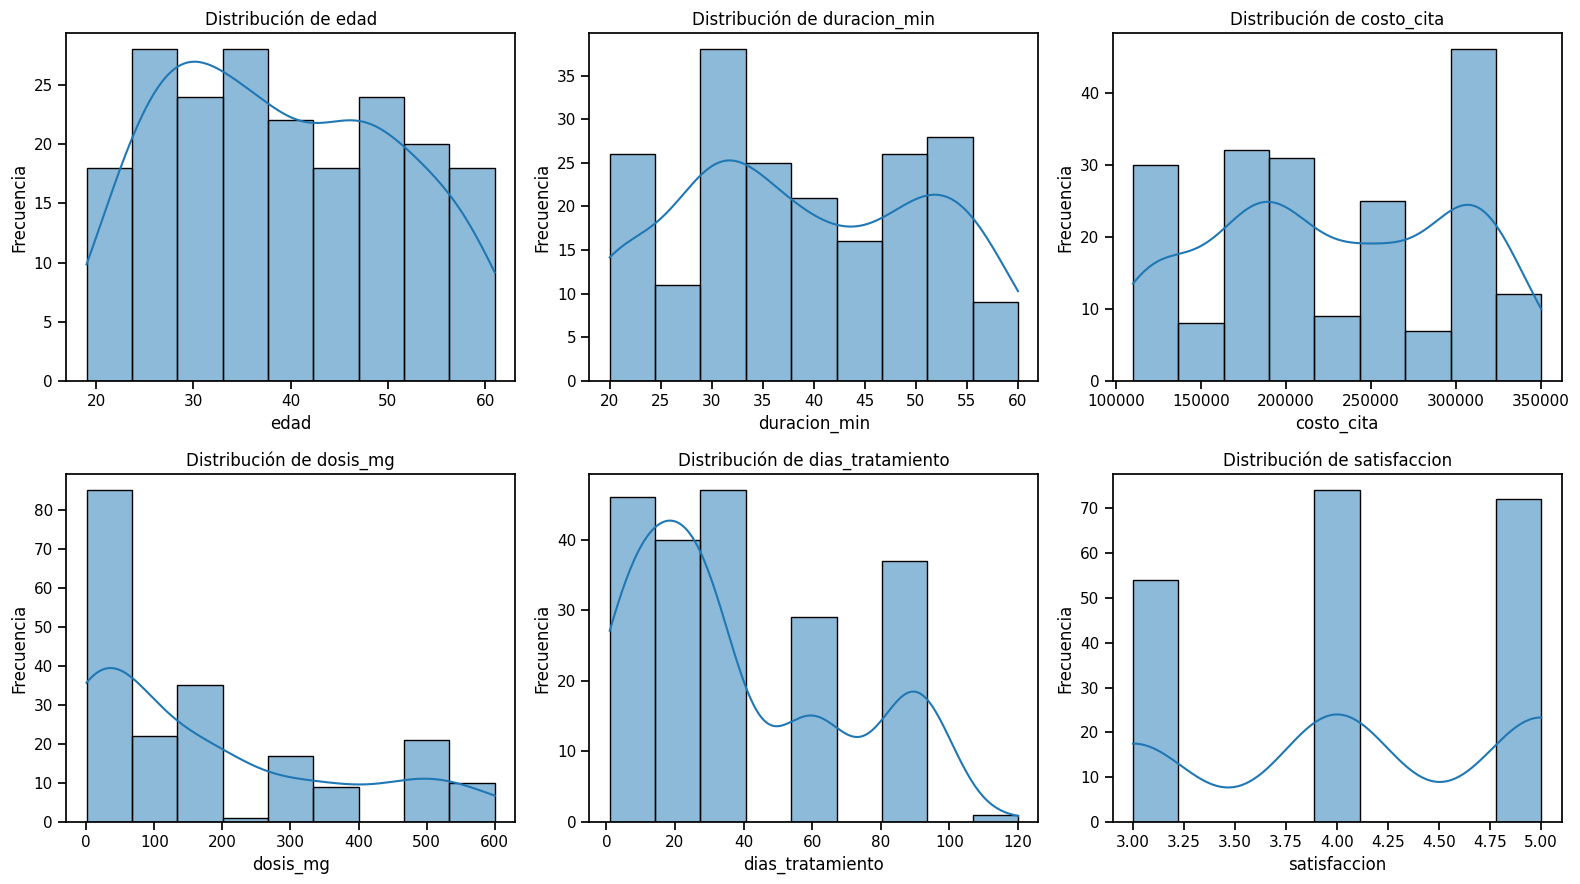

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, variable in zip(axes, variables_numericas):
    sns.histplot(
        data=df,
        x=variable,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación de las distribuciones

Los histogramas permiten observar cómo se distribuyen las seis variables numéricas utilizadas en el análisis.

- **Edad:** los pacientes se encuentran distribuidos entre aproximadamente 19 y 60 años aproximadamente. La distribución es relativamente amplia y no presenta una concentración extrema en un único rango de edad.

- **Duración de la cita:** las consultas tienen duraciones entre 20 y 60 minutos. Se observan concentraciones importantes alrededor de los 30–35 minutos y de los 50–55 minutos, lo que sugiere que existen citas de distinta duración.

- **Costo de la cita:** los costos se distribuyen aproximadamente entre $110.000 y $350.000. Se observan varios niveles de concentración, especialmente alrededor de los $180.000–$210.000 y cerca de los $300.000, indicando diferencias importantes en el valor de las consultas.

- **Dosis del medicamento:** presenta una distribución claramente asimétrica hacia la derecha. La mayoría de las observaciones se concentra en dosis bajas, mientras que un grupo menor presenta dosis considerablemente más altas, llegando hasta 600 mg.

- **Días de tratamiento:** existe una mayor concentración en tratamientos de corta y mediana duración, aunque también aparecen tratamientos más prolongados, alcanzando hasta 120 días.

- **Satisfacción:** únicamente se observan valores de 3, 4 y 5. La mayor parte de las citas presenta niveles de satisfacción de 4 y 5, lo que indica una percepción generalmente favorable del servicio.

### Conclusión

Las variables presentan comportamientos y escalas diferentes, especialmente en **costo, dosis y días de tratamiento**. Esta heterogeneidad es relevante para el análisis posterior y refuerza la necesidad de escalar las variables antes de aplicar **PCA y K-Means**, evitando que aquellas con valores numéricamente mayores tengan una influencia desproporcionada en el modelo.

## 8.2. Boxplots

Un boxplot permite visualizar mediana, cuartiles, dispersión y observaciones potencialmente atípicas.

⚠️ Un punto fuera de los “bigotes” **no significa automáticamente un error**. En datos clínicos puede ser una observación real e importante.

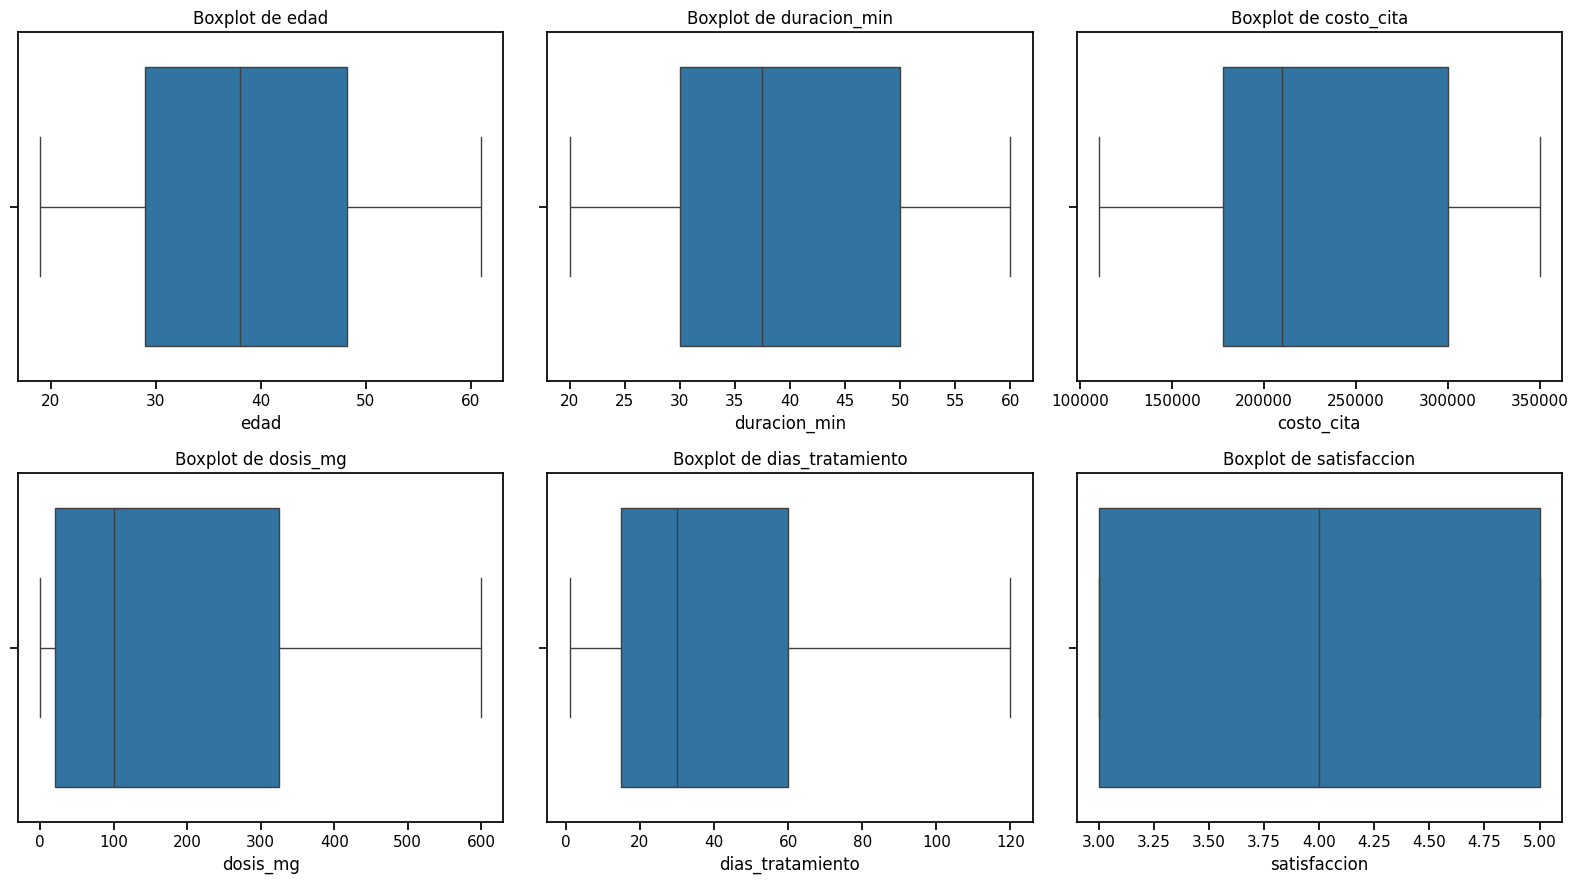

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, variable in zip(axes, variables_numericas):
    sns.boxplot(
        x=df[variable],
        ax=ax
    )
    ax.set_title(f"Boxplot de {variable}")

plt.tight_layout()
plt.show()

### Interpretación de los boxplots

Los boxplots permiten observar la distribución, dispersión y posibles valores atípicos de las seis variables numéricas.

- **`Edad`:** la mediana se encuentra alrededor de los 38 años. La mayor parte de los pacientes se concentra aproximadamente entre 29 y 48 años. No se observan valores atípicos.

- **`Duración de la cita`:** la mediana es cercana a 37,5 minutos y el 50 % central de las consultas se encuentra aproximadamente entre 30 y 50 minutos. No se identifican valores atípicos.

- **`Costo de la cita`:** la mediana es aproximadamente de $210.000$ y la mayor parte de los costos se concentra entre $177.500$ y $300.000$. La dispersión es amplia, pero no se observan valores atípicos.

- **`Dosis del medicamento`:** presenta una mayor dispersión que otras variables. La mediana es de aproximadamente 100 mg y los valores alcanzan hasta 600 mg. La caja se encuentra desplazada hacia los valores bajos, lo que evidencia una distribución asimétrica hacia valores altos. No se observan puntos identificados como atípicos.

- **`Días de tratamiento`:** la mediana es aproximadamente de 30 días. La mayoría de los tratamientos se encuentra entre 15 y 60 días, aunque algunos alcanzan hasta 120 días. Se observa una mayor extensión hacia tratamientos largos, pero sin valores atípicos según el criterio utilizado.

- **`Satisfacción`:** los valores se encuentran únicamente entre 3 y 5, con una mediana de 4. Esto confirma que las evaluaciones del servicio se concentran en niveles medios y altos.

### Conclusión

Los boxplots no muestran valores atípicos en ninguna de las seis variables analizadas. Sin embargo, variables como **`dosis_mg`** y **`dias_tratamiento`** presentan mayor dispersión y asimetría. Por tanto, no es necesario eliminar observaciones antes del modelado y se pueden conservar los **200 registros** para las etapas posteriores de escalado, PCA y K-Means.

## 8.3. Matriz de correlación

La correlación lineal toma valores entre `-1` y `1`.

- Cerca de `1`: relación positiva fuerte.
- Cerca de `-1`: relación negativa fuerte.
- Cerca de `0`: poca relación lineal.

PCA puede ser especialmente útil cuando varias variables contienen información parcialmente redundante.

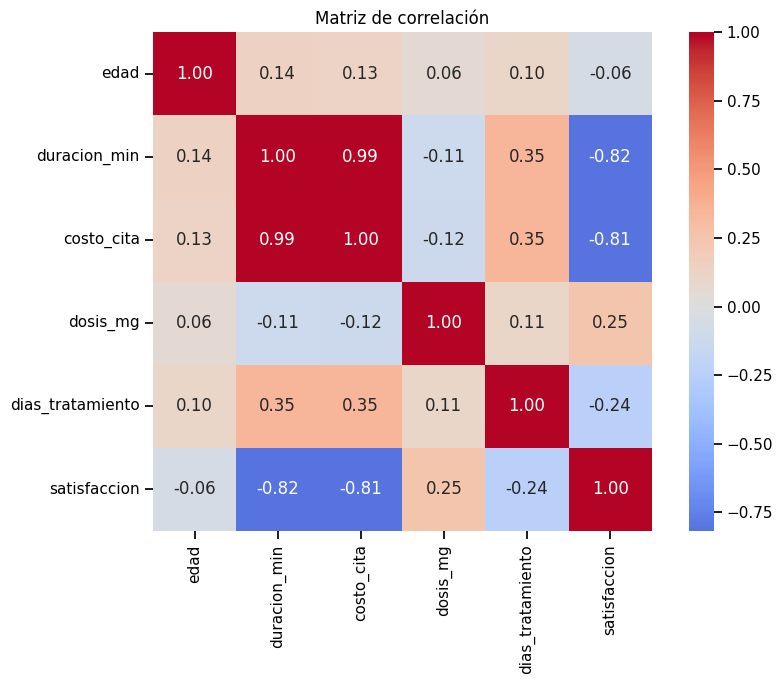

In [ ]:
correlacion = df[variables_numericas].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación permite identificar qué tan relacionadas están las variables numéricas entre sí.

- **Duración de la cita y costo de la cita:** presentan una correlación **muy alta y positiva de 0,99**. Esto indica que, en estos datos, las citas de mayor duración tienden a tener costos más altos.

- **Duración de la cita y satisfacción:** muestran una correlación **alta y negativa de -0,82**. En este conjunto de datos, las consultas más largas tienden a asociarse con menores niveles de satisfacción.

- **Costo de la cita y satisfacción:** presentan igualmente una correlación **alta y negativa de -0,81**. Esto sugiere que las citas más costosas tienden a estar relacionadas con niveles de satisfacción más bajos.

- **Duración de la cita y días de tratamiento:** presentan una correlación positiva moderada de **0,35**.

- **Costo de la cita y días de tratamiento:** también muestran una correlación positiva moderada de **0,35**.

- **Dosis del medicamento y satisfacción:** presentan una correlación positiva baja de **0,25**.

- **Días de tratamiento y satisfacción:** muestran una correlación negativa baja de **-0,24**.

- **Edad:** presenta correlaciones bajas con todas las demás variables, por lo que no parece tener una relación lineal fuerte con duración, costo, dosis, días de tratamiento o satisfacción.

### Conclusión

Las relaciones más importantes se encuentran entre **duracion_min, costo_cita y satisfaccion**. En particular, duración y costo están fuertemente relacionadas entre sí, mientras que ambas presentan una relación negativa importante con la satisfacción.

Estas correlaciones muestran que algunas variables contienen información relacionada o parcialmente redundante, lo que respalda el uso de **PCA** para resumir la información antes de aplicar K-Means.

> **Importante:** una correlación indica asociación entre variables, pero no implica que una variable sea la causa de otra.

# 9. Preparación de los datos

Para PCA y K-Means se trabajará únicamente con las seis variables numéricas indicadas en el taller.

Como ya se comprobó:

- No existen valores faltantes.
- No existen registros duplicados.

Por tanto, no es necesario imputar datos ni eliminar observaciones por esas causas.

In [ ]:
variables_numericas = [
    "edad",
    "duracion_min",
    "costo_cita",
    "satisfaccion",
    "dosis_mg",
    "dias_tratamiento"
]

X = df[variables_numericas].copy()

print("Dimensiones de los datos para Machine Learning:", X.shape)
display(X.head())

Dimensiones de los datos para Machine Learning: (200, 6)


,edad,duracion_min,costo_cita,satisfaccion,dosis_mg,dias_tratamiento
0,34,45,"250,000.0000",5,50.0000,30
1,45,30,"180,000.0000",4,400.0000,10
2,28,25,"150,000.0000",5,20.0000,15
3,52,60,"320,000.0000",3,50.0000,20
4,19,20,"120,000.0000",5,0.5000,1


## 9.1. Revisión de valores atípicos

Los boxplots anteriores permiten observar posibles valores extremos.  
A continuación se realiza una verificación automática para conocer cuántos posibles outliers existen en cada variable.

In [ ]:
resumen_outliers = []

for variable in variables_numericas:

    Q1 = X[variable].quantile(0.25)
    Q3 = X[variable].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad = (
        (X[variable] < limite_inferior) |
        (X[variable] > limite_superior)
    ).sum()

    resumen_outliers.append({
        "variable": variable,
        "outliers": cantidad
    })

outliers = pd.DataFrame(resumen_outliers)

display(outliers)

print(
    "Total de posibles valores atípicos:",
    outliers["outliers"].sum()
)

,variable,outliers
0,edad,0
1,duracion_min,0
2,costo_cita,0
3,satisfaccion,0
4,dosis_mg,0
5,dias_tratamiento,0


Total de posibles valores atípicos: 0


### Tratamiento

Si no se detectan valores atípicos, los datos continúan sin modificaciones.

Si aparece algún valor extremo, se limita únicamente al rango identificado para evitar que tenga un peso excesivo en PCA y K-Means, sin eliminar la cita del conjunto de datos.

In [ ]:
X_modelo = X.copy()

for variable in variables_numericas:

    Q1 = X_modelo[variable].quantile(0.25)
    Q3 = X_modelo[variable].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    X_modelo[variable] = X_modelo[variable].clip(
        lower=limite_inferior,
        upper=limite_superior
    )

print("Datos preparados correctamente.")
print("Número de registros conservados:", len(X_modelo))

Datos preparados correctamente.
Número de registros conservados: 200


# 10. Escalado de las variables

Antes de aplicar PCA y K-Means se estandarizan las variables.

Esto es necesario porque las variables tienen escalas muy diferentes. Por ejemplo, `costo_cita` puede tener valores de cientos de miles, mientras que `satisfaccion` tiene valores mucho más pequeños.

In [ ]:
scaler = StandardScaler()

X_escalado = scaler.fit_transform(X_modelo)

X_escalado = pd.DataFrame(
    X_escalado,
    columns=variables_numericas,
    index=X_modelo.index
)

display(X_escalado.head())

,edad,duracion_min,costo_cita,satisfaccion,dosis_mg,dias_tratamiento
0,-0.4336,0.5113,0.3207,1.1539,-0.6920,-0.2479
1,0.5128,-0.7158,-0.6660,-0.1141,1.1704,-0.8949
2,-0.9499,-1.1248,-1.0889,1.1539,-0.8517,-0.7332
3,1.1151,1.7383,1.3074,-1.3822,-0.6920,-0.5714
4,-1.7243,-1.5338,-1.5118,1.1539,-0.9554,-1.1860


## 10.1. Verificación del escalado

In [ ]:
verificacion_escalado = pd.DataFrame({
    "media": X_escalado.mean(),
    "desviacion_estandar": X_escalado.std(ddof=0)
})

display(verificacion_escalado.round(4))

,media,desviacion_estandar
edad,0.0000,1.0000
duracion_min,0.0000,1.0000
costo_cita,-0.0000,1.0000
satisfaccion,0.0000,1.0000
dosis_mg,-0.0000,1.0000
dias_tratamiento,0.0000,1.0000


# 11. Análisis de Componentes Principales — PCA

Primero se ejecuta PCA utilizando todas las componentes para conocer cuánta información explica cada una.

In [ ]:
pca = PCA()

componentes_pca = pca.fit_transform(X_escalado)

varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

tabla_varianza = pd.DataFrame({
    "Componente": [
        f"PC{i}"
        for i in range(1, len(varianza_explicada) + 1)
    ],
    "Varianza_explicada_%": varianza_explicada * 100,
    "Varianza_acumulada_%": varianza_acumulada * 100
})

display(tabla_varianza.round(2))

,Componente,Varianza_explicada_%,Varianza_acumulada_%
0,PC1,49.2400,49.2400
1,PC2,19.4900,68.7300
2,PC3,15.4400,84.1700
3,PC4,12.0300,96.2100
4,PC5,3.6200,99.8200
5,PC6,0.1800,100.0000


### Interpretación de la varianza explicada

El análisis de componentes principales muestra cómo se distribuye la información entre las seis componentes obtenidas.

- **PC1** explica el **49,24 %** de la varianza total, por lo que es la componente que concentra la mayor cantidad de información.
- **PC2** explica un **19,49 %** adicional. En conjunto, **PC1 y PC2 acumulan el 68,73 %** de la varianza.
- **PC3** aporta un **15,44 %**, llevando la varianza acumulada hasta **84,17 %**.
- Las componentes restantes aportan porcentajes menores:
  - **PC4:** 12,03 %
  - **PC5:** 3,62 %
  - **PC6:** 0,18 %



## 11.1. Gráfica de varianza explicada

La gráfica permite observar cuánto aporta cada componente y cuánta varianza se acumula al ir agregando componentes.

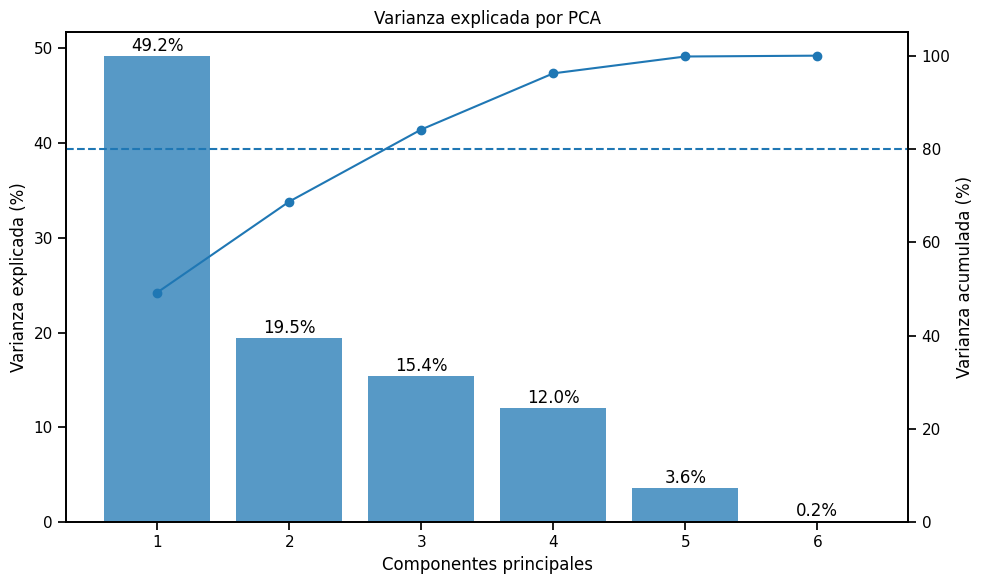

In [ ]:
componentes = np.arange(
    1,
    len(varianza_explicada) + 1
)

fig, ax1 = plt.subplots(figsize=(10, 6))

barras = ax1.bar(
    componentes,
    varianza_explicada * 100,
    alpha=0.75
)

ax1.set_xlabel("Componentes principales")
ax1.set_ylabel("Varianza explicada (%)")
ax1.set_xticks(componentes)
ax1.set_title("Varianza explicada por PCA")

for barra, porcentaje in zip(
    barras,
    varianza_explicada * 100
):
    ax1.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{porcentaje:.1f}%",
        ha="center"
    )

ax2 = ax1.twinx()

ax2.plot(
    componentes,
    varianza_acumulada * 100,
    marker="o"
)

ax2.axhline(
    80,
    linestyle="--",
    label="80%"
)

ax2.set_ylabel("Varianza acumulada (%)")
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## 11.2. Número de componentes que explican al menos el 80 %

El taller solicita identificar cuántas componentes son necesarias para alcanzar como mínimo el 80 % de la varianza.

In [ ]:
n_componentes_80 = np.argmax(
    varianza_acumulada >= 0.80
) + 1

print(
    f"Número de componentes necesarias: {n_componentes_80}"
)

print(
    "Varianza acumulada:",
    f"{varianza_acumulada[n_componentes_80 - 1] * 100:.2f}%"
)

Número de componentes necesarias: 3
Varianza acumulada: 84.17%


# 12. Loadings de PCA

Los loadings permiten identificar cuáles variables tienen mayor participación en cada componente principal.

In [ ]:
nombres_componentes = [
    f"PC{i}"
    for i in range(1, len(variables_numericas) + 1)
]

loadings = pd.DataFrame(
    pca.components_.T,
    index=variables_numericas,
    columns=nombres_componentes
)

display(loadings.round(3))

,PC1,PC2,PC3,PC4,PC5,PC6
edad,0.1040,0.4680,0.8760,0.0230,-0.0500,-0.0040
duracion_min,0.5640,0.0050,-0.0400,-0.1780,0.3700,0.7150
costo_cita,0.5630,-0.0020,-0.0410,-0.1730,0.4040,-0.6990
satisfaccion,-0.5200,0.1850,0.0060,0.1420,0.8210,0.0200
dosis_mg,-0.1130,0.7190,-0.3630,-0.5660,-0.1320,-0.0080
dias_tratamiento,0.2660,0.4790,-0.3120,0.7730,-0.0710,-0.0020


### Interpretación de los loadings

Los *`loadings`* permiten identificar qué variables tienen mayor peso en cada componente principal. Para interpretarlos, se observa principalmente el valor absoluto: cuanto mayor sea, mayor es la influencia de esa variable sobre la componente.

- **PC1:** está dominada principalmente por **duracion_min (0,564)** y **costo_cita (0,563)**, seguidas por **satisfaccion (-0,520)**. Esto indica que la primera componente resume sobre todo el comportamiento relacionado con la duración y el costo de las consultas, en contraste con la satisfacción.

- **PC2:** está dominada por **dosis_mg (0,719)**, seguida por **dias_tratamiento (0,479)** y **edad (0,468)**. Esta componente representa principalmente características relacionadas con el tratamiento y, en menor medida, con la edad del paciente.

- **PC3:** está fuertemente asociada con **edad (0,876)**, por lo que esta componente recoge principalmente diferencias relacionadas con la edad de los pacientes.

- **PC4:** está dominada por **dias_tratamiento (0,773)** y presenta también una contribución importante de **dosis_mg (-0,566)**.

- **PC5:** está dominada por **satisfaccion (0,821)**, con una contribución secundaria de **costo_cita (0,404)** y **duracion_min (0,370)**.

- **PC6:** está determinada principalmente por **duracion_min (0,715)** y **costo_cita (-0,699)**.

### Conclusión

Las dos primeras componentes, que son las más importantes para la interpretación inicial, muestran dos patrones principales:

- **PC1** resume principalmente diferencias en **duración, costo y satisfacción**.
- **PC2** resume principalmente diferencias en **dosis, días de tratamiento y edad**.

Esto facilita reducir la información original y entender qué variables son las que más contribuyen a separar los patrones presentes en los datos.

## 12.1. Gráfica de loadings

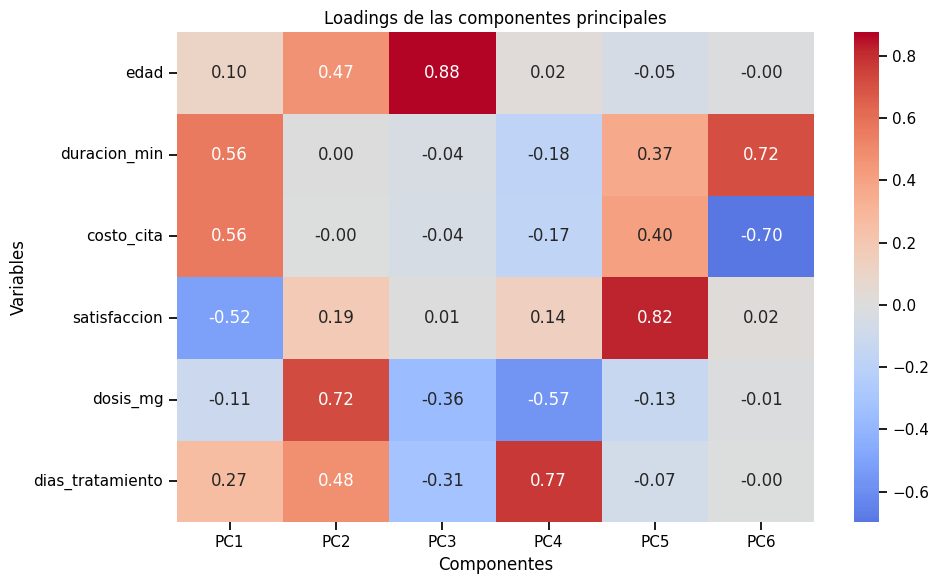

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    loadings,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Loadings de las componentes principales")
plt.xlabel("Componentes")
plt.ylabel("Variables")

plt.tight_layout()
plt.show()

## 12.2. Variables que dominan PC1 y PC2

In [ ]:
dominantes_pc1 = (
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
)

dominantes_pc2 = (
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
)

print("Variables con mayor peso en PC1:")
display(
    loadings.loc[
        dominantes_pc1.index,
        ["PC1"]
    ].round(3)
)

print("\nVariables con mayor peso en PC2:")
display(
    loadings.loc[
        dominantes_pc2.index,
        ["PC2"]
    ].round(3)
)

Variables con mayor peso en PC1:


,PC1
duracion_min,0.5640
costo_cita,0.5630
satisfaccion,-0.5200
dias_tratamiento,0.2660
dosis_mg,-0.1130
edad,0.1040



Variables con mayor peso en PC2:


,PC2
dosis_mg,0.7190
dias_tratamiento,0.4790
edad,0.4680
satisfaccion,0.1850
duracion_min,0.0050
costo_cita,-0.0020


### Interpretación de las variables con mayor peso en PC1 y PC2

#### PC1

La primera componente principal está explicada principalmente por:

- **duracion_min (0,564)**
- **costo_cita (0,563)**
- **satisfaccion (-0,520)**

Esto indica que **PC1 representa principalmente el comportamiento relacionado con la duración y el costo de las consultas**, en contraste con la satisfacción.

En otras palabras, las citas con valores altos en duración y costo tienden a ubicarse en una dirección de PC1, mientras que la satisfacción se relaciona en sentido contrario dentro de esta componente.

Las demás variables tienen una influencia menor en PC1:

- `dias_tratamiento`: 0,266
- `dosis_mg`: -0,113
- `edad`: 0,104

Por tanto, **PC1 puede interpretarse principalmente como una componente asociada con duración, costo y satisfacción de la cita**.

---

#### PC2

La segunda componente principal está explicada principalmente por:

- **dosis_mg (0,719)**
- **dias_tratamiento (0,479)**
- **edad (0,468)**

La variable con mayor peso es claramente **dosis_mg**, seguida por los días de tratamiento y la edad.

Por el contrario, `duracion_min (0,005)` y `costo_cita (-0,002)` prácticamente no tienen influencia sobre PC2.

Por esta razón, **PC2 puede interpretarse principalmente como una componente relacionada con las características del tratamiento y la edad del paciente**.

### Conclusión

Las dos primeras componentes resumen aspectos diferentes de los datos:

- **PC1:** está asociada principalmente con **duración, costo y satisfacción**.
- **PC2:** está asociada principalmente con **dosis, días de tratamiento y edad**.

Esta separación facilita la interpretación del PCA, ya que permite identificar qué grupos de variables explican la mayor parte de la variabilidad presente en las citas médicas.

# 13. Datos reducidos con PCA

Para K-Means se conservarán únicamente las componentes necesarias para explicar al menos el 80 % de la varianza.

In [ ]:
X_pca = componentes_pca[
    :,
    :n_componentes_80
]

print(
    "Dimensiones antes de PCA:",
    X_escalado.shape
)

print(
    "Dimensiones después de PCA:",
    X_pca.shape
)

Dimensiones antes de PCA: (200, 6)
Dimensiones después de PCA: (200, 3)


## 13.1. Visualización de las dos primeras componentes

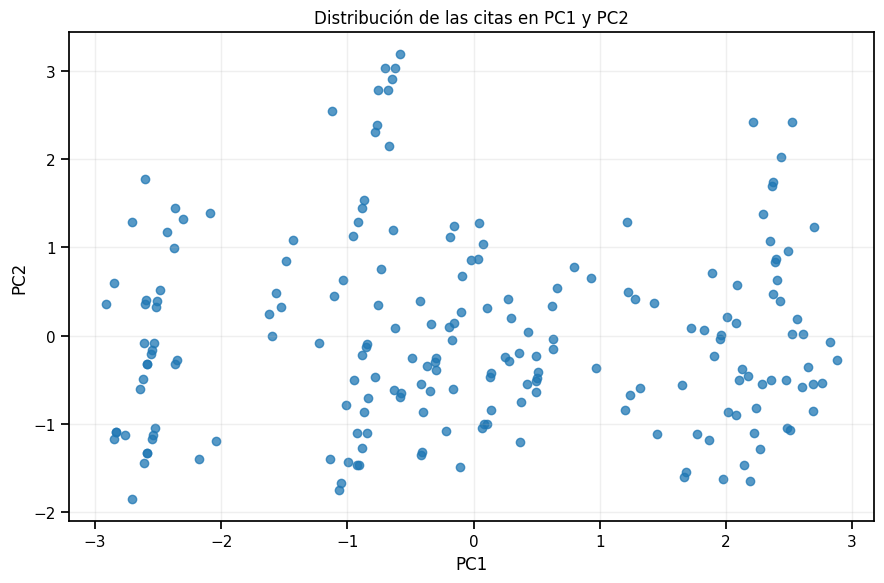

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    componentes_pca[:, 0],
    componentes_pca[:, 1],
    alpha=0.75
)

plt.title("Distribución de las citas en PC1 y PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 14. Selección del número de clústeres — Método del codo

Se probarán diferentes valores de `k` y se observará la inercia para identificar el punto donde agregar más clústeres deja de producir una mejora importante.

In [ ]:
inercias = []

valores_k = range(2, 9)

for k in valores_k:

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    modelo.fit(X_pca)

    inercias.append(
        modelo.inertia_
    )

tabla_codo = pd.DataFrame({
    "k": list(valores_k),
    "inercia": inercias
})

display(tabla_codo.round(2))

,k,inercia
0,2,584.1700
1,3,463.7300
2,4,366.9900
3,5,288.8600
4,6,241.1700
5,7,207.1600
6,8,181.5900


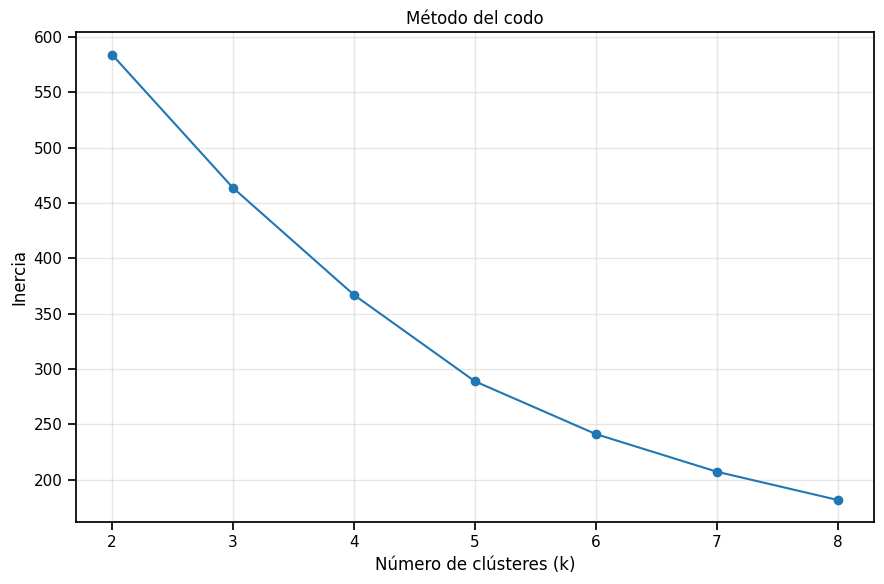

In [ ]:
plt.figure(figsize=(9, 6))

plt.plot(
    list(valores_k),
    inercias,
    marker="o"
)

plt.title("Método del codo")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Inercia")

plt.xticks(list(valores_k))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14.1. Identificación automática del codo

In [ ]:
codo = KneeLocator(
    list(valores_k),
    inercias,
    curve="convex",
    direction="decreasing"
)

k_optimo = codo.elbow

print(
    "Número de clústeres sugerido por el método del codo:",
    k_optimo
)

if k_optimo is None:
    raise ValueError(
        "No se detectó automáticamente un codo claro. "
        "Revise la gráfica y asigne manualmente el valor de k."
    )

Número de clústeres sugerido por el método del codo: 5


# 15. Modelo K-Means

Se entrena K-Means utilizando el número de clústeres identificado con el método del codo.

In [ ]:
kmeans = KMeans(
    n_clusters=int(k_optimo),
    random_state=42,
    n_init=50
)

clusters = kmeans.fit_predict(
    X_pca
)

df_resultados = df.copy()

df_resultados["cluster_ml"] = clusters
df_resultados["pc1"] = componentes_pca[:, 0]
df_resultados["pc2"] = componentes_pca[:, 1]

display(df_resultados.head())

,id_cita,especialidad,edad,duracion_min,costo_cita,dosis_mg,dias_tratamiento,satisfaccion,cluster_ml,pc1,pc2
0,1,Cardiología,34,45,"250,000.0000",50.0000,30,5,3,-0.1641,-0.6044
1,2,Ortopedia,45,30,"180,000.0000",400.0000,10,4,2,-1.0361,0.6303
2,3,Dermatología,28,25,"150,000.0000",20.0000,15,5,4,-2.0455,-1.1973
3,4,Neurología,52,60,"320,000.0000",50.0000,20,3,1,2.4780,-0.5002
4,5,Pediatría,19,20,"120,000.0000",0.5000,1,5,4,-2.7038,-1.8522


## 15.1. Visualización de los clústeres

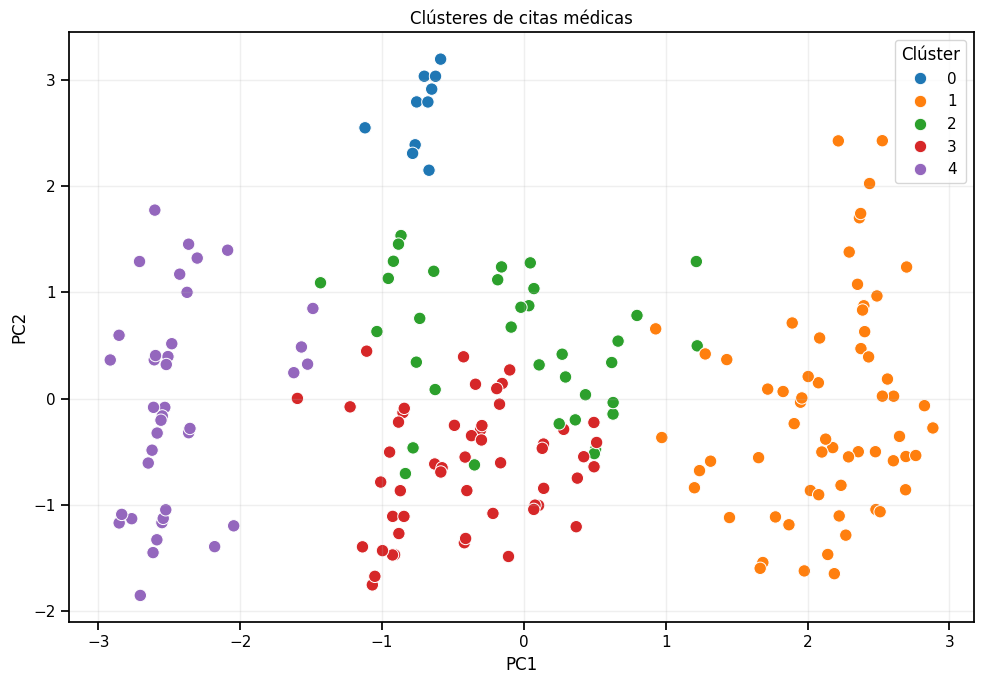

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df_resultados,
    x="pc1",
    y="pc2",
    hue="cluster_ml",
    palette="tab10",
    s=80
)

plt.title("Clústeres de citas médicas")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Clúster")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 16. Interpretación de los clústeres

Ahora se regresa a las variables originales para describir el perfil promedio de cada grupo.

In [ ]:
perfil_clusters = (
    df_resultados
    .groupby("cluster_ml")[variables_numericas]
    .mean()
    .round(2)
)

display(perfil_clusters)

,edad,duracion_min,costo_cita,satisfaccion,dosis_mg,dias_tratamiento
cluster_ml,,,,,,
0,41.1000,35.0000,"205,000.0000",5.0000,600.0000,90.0000
1,40.3100,53.6300,"312,741.9400",3.1500,146.0500,50.4800
2,53.0600,37.5700,"221,428.5700",4.2600,155.7100,37.1400
3,29.5800,35.4800,"210,384.6200",4.2100,107.5200,36.7300
4,36.6600,22.3200,"129,756.1000",5.0000,241.8200,7.1500


### Interpretación del perfil promedio de los clústeres

La tabla muestra las características promedio de cada uno de los cinco clústeres identificados mediante K-Means.

#### Clúster 0

Este grupo presenta:

- Edad promedio de **41 años** aproximadamente.
- Duración promedio de la cita de **35 minutos**.
- Costo promedio de **$205.000**.
- Satisfacción promedio de **5,0**, la más alta posible.
- Dosis promedio de **600 mg**, la más alta de todos los clústeres.
- Tratamientos de **90 días** en promedio, también el valor más alto.

Este clúster se caracteriza principalmente por **tratamientos de mayor dosis y mayor duración**, acompañados de un nivel de satisfacción alto.

---

#### Clúster 1

Este grupo presenta:

- Edad promedio de **40,31 años**.
- Duración promedio de la cita de **53,63 minutos**, la más alta entre los grupos.
- Costo promedio de **$312.741,94**, también el más alto.
- Satisfacción promedio de **3,15**, la más baja de los cinco clústeres.
- Dosis promedio de **146,05 mg**.
- Tratamiento promedio de **50,48 días**.

Este clúster reúne las **citas más largas y costosas**, y al mismo tiempo presenta el **menor nivel promedio de satisfacción**.

---

#### Clúster 2

Este grupo presenta:

- Edad promedio de **53,06 años**, la más alta entre los clústeres.
- Duración promedio de **37,57 minutos**.
- Costo promedio de **$221.428,57**.
- Satisfacción promedio de **4,26**.
- Dosis promedio de **155,71 mg**.
- Tratamientos de **37,14 días** en promedio.

Su principal característica es concentrar a los **pacientes de mayor edad**, mientras que las demás variables se mantienen en niveles intermedios frente a los otros grupos.

---

#### Clúster 3

Este grupo presenta:

- Edad promedio de **29,58 años**, la más baja de los cinco clústeres.
- Duración promedio de la cita de **35,48 minutos**.
- Costo promedio de **$210.384,62**.
- Satisfacción promedio de **4,21**.
- Dosis promedio de **107,52 mg**, relativamente baja.
- Tratamientos de **36,73 días** en promedio.

Este clúster se caracteriza principalmente por incluir a los **pacientes más jóvenes** y por presentar una dosis promedio relativamente baja.

---

#### Clúster 4

Este grupo presenta:

- Edad promedio de **36,66 años**.
- Duración promedio de la cita de **22,32 minutos**, la más baja.
- Costo promedio de **$129.756,10**, también el menor.
- Satisfacción promedio de **5,0**.
- Dosis promedio de **241,82 mg**.
- Tratamientos de aproximadamente **7,15 días**, los más cortos.

Este clúster corresponde a **consultas más breves y económicas**, con tratamientos de corta duración y un nivel de satisfacción alto.

### Conclusión

Los cinco clústeres presentan perfiles claramente diferenciados. El **clúster 1** concentra las citas más largas y costosas y presenta la menor satisfacción; el **clúster 0** se distingue por las mayores dosis y duración del tratamiento; el **clúster 2** agrupa a los pacientes de mayor edad; el **clúster 3** concentra a los pacientes más jóvenes; y el **clúster 4** reúne las consultas más cortas y económicas, con tratamientos de menor duración.

Estos resultados permiten caracterizar diferentes patrones de atención dentro de la clínica y sirven como base para proponer acciones operativas diferenciadas para cada segmento.

## 16.1. Tamaño de cada clúster

In [ ]:
tamano_clusters = (
    df_resultados["cluster_ml"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_ml")
    .reset_index(name="numero_citas")
)

tamano_clusters["porcentaje_%"] = (
    tamano_clusters["numero_citas"] /
    len(df_resultados) *
    100
)

display(tamano_clusters.round(2))

,cluster_ml,numero_citas,porcentaje_%
0,0,10,5.0000
1,1,62,31.0000
2,2,35,17.5000
3,3,52,26.0000
4,4,41,20.5000


### Interpretación del tamaño de los clústeres

Los 200 registros fueron distribuidos en cinco clústeres con tamaños diferentes:

- **Clúster 0:** contiene **10 citas**, equivalentes al **5 %** del total. Es el grupo más pequeño.
- **Clúster 1:** contiene **62 citas**, correspondientes al **31 %** del total. Es el clúster con mayor cantidad de observaciones.
- **Clúster 2:** agrupa **35 citas**, que representan el **17,5 %**.
- **Clúster 3:** contiene **52 citas**, equivalentes al **26 %** del conjunto de datos.
- **Clúster 4:** reúne **41 citas**, correspondientes al **20,5 %**.

### Conclusión

La distribución muestra que los clústeres **1 y 3 concentran la mayor parte de las citas**, representando conjuntamente el **57 %** de los registros.

El **clúster 0** es considerablemente más pequeño, con solo el **5 %** de las observaciones. Esto no significa que sea menos importante, sino que representa un patrón menos frecuente dentro de los datos.

En general, K-Means identificó cinco segmentos de diferentes tamaños, lo que indica que los perfiles encontrados no aparecen con la misma frecuencia dentro de las 200 citas analizadas.

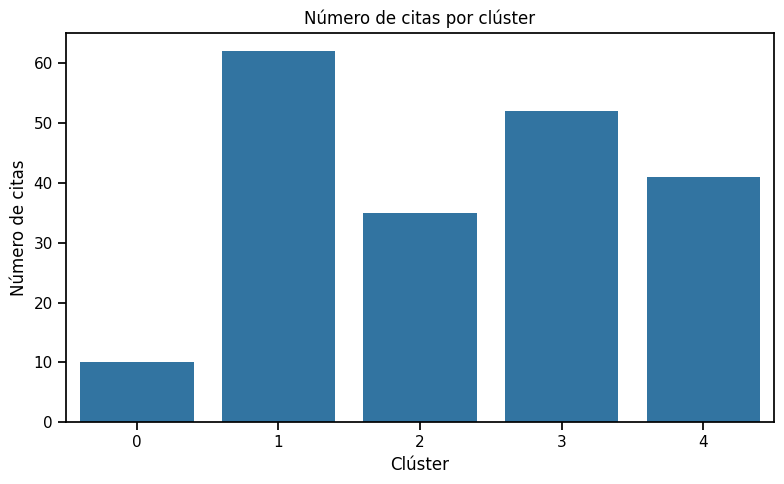

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_resultados,
    x="cluster_ml"
)

plt.title("Número de citas por clúster")
plt.xlabel("Clúster")
plt.ylabel("Número de citas")

plt.tight_layout()
plt.show()

# 17. Especialidad predominante por clúster

Esta comparación permite identificar qué especialidad médica aparece con mayor frecuencia dentro de cada grupo.

In [ ]:
tabla_especialidades = pd.crosstab(
    df_resultados["cluster_ml"],
    df_resultados["especialidad"]
)

display(tabla_especialidades)

especialidad,Cardiología,Dermatología,Ginecología,Neurología,Ortopedia,Pediatría
cluster_ml,,,,,,
0,0,0,10,0,0,0
1,28,1,0,33,0,0
2,3,8,9,1,14,0
3,5,22,8,0,17,0
4,0,2,4,0,0,35


### Interpretación de la especialidad predominante por clúster

La tabla muestra cómo se distribuyen las especialidades médicas dentro de cada uno de los cinco clústeres.

- **Clúster 0:** está compuesto completamente por **Ginecología**, con **10 de 10 citas**. En este grupo, Ginecología representa el **100 %** de las observaciones.

- **Clúster 1:** está concentrado principalmente en **Neurología**, con **33 citas**, seguido muy de cerca por **Cardiología**, con **28 citas**. También aparece una cita de Dermatología. Por tanto, Neurología es la especialidad predominante, aunque el grupo también tiene una participación importante de Cardiología.

- **Clúster 2:** presenta una composición más diversa. La especialidad con mayor frecuencia es **Ortopedia**, con **14 citas**, seguida por Ginecología con 9, Dermatología con 8, Cardiología con 3 y Neurología con 1.

- **Clúster 3:** está dominado por **Dermatología**, con **22 citas**, seguida por Ortopedia con 17, Ginecología con 8 y Cardiología con 5.

- **Clúster 4:** está fuertemente concentrado en **Pediatría**, con **35 de 41 citas**, mientras que Ginecología aporta 4 y Dermatología 2.

### Conclusión

La especialidad predominante en cada clúster es:

- **Clúster 0:** Ginecología
- **Clúster 1:** Neurología
- **Clúster 2:** Ortopedia
- **Clúster 3:** Dermatología
- **Clúster 4:** Pediatría

Sin embargo, es importante recordar que **la variable `especialidad` no fue utilizada para construir los clústeres**. Se usa únicamente después del modelado para caracterizar los grupos obtenidos.

Por tanto, estos resultados no significan que la especialidad haya causado la formación de los clústeres, sino que permite identificar qué especialidades aparecen con mayor frecuencia dentro de cada segmento.

In [ ]:
especialidad_predominante = (
    df_resultados
    .groupby("cluster_ml")["especialidad"]
    .agg(
        lambda x: x.value_counts().idxmax()
    )
    .to_frame("especialidad_predominante")
)

display(especialidad_predominante)

,especialidad_predominante
cluster_ml,
0,Ginecología
1,Neurología
2,Ortopedia
3,Dermatología
4,Pediatría


# 18. Comparación: PCA y K-Means sin escalado

El taller solicita mostrar qué cambia cuando las variables se utilizan en sus escalas originales.

In [ ]:
pca_sin_escalar = PCA()

componentes_sin_escalar = pca_sin_escalar.fit_transform(
    X_modelo
)

varianza_sin_escalar = (
    pca_sin_escalar.explained_variance_ratio_
)

comparacion_varianza = pd.DataFrame({
    "Componente": [
        f"PC{i}"
        for i in range(1, len(variables_numericas) + 1)
    ],
    "Con_escalado_%": varianza_explicada * 100,
    "Sin_escalado_%": varianza_sin_escalar * 100
})

display(comparacion_varianza.round(2))

,Componente,Con_escalado_%,Sin_escalado_%
0,PC1,49.2400,100.0000
1,PC2,19.4900,0.0000
2,PC3,15.4400,0.0000
3,PC4,12.0300,0.0000
4,PC5,3.6200,0.0000
5,PC6,0.1800,0.0000


### Interpretación de PCA con y sin escalado

La comparación muestra una diferencia muy marcada entre aplicar PCA con las variables escaladas y hacerlo directamente con sus valores originales.

- **Con escalado**, la varianza se distribuye entre varias componentes:
  - **PC1:** 49,24 %
  - **PC2:** 19,49 %
  - **PC3:** 15,44 %
  - **PC4:** 12,03 %
  - **PC5:** 3,62 %
  - **PC6:** 0,18 %

  En este caso, las primeras tres componentes acumulan **84,17 % de la varianza**, por lo que varias variables contribuyen de manera más equilibrada al análisis.

- **Sin escalado**, **PC1 concentra prácticamente el 100 % de la varianza**, mientras que las demás componentes aportan valores cercanos a 0 %.

Esto ocurre porque las variables originales tienen escalas muy diferentes. En particular, **`costo_cita`** maneja valores numéricos mucho mayores que variables como `satisfaccion`, `edad` o `dias_tratamiento`, por lo que termina dominando el PCA cuando no se realiza estandarización.

### Conclusión

El resultado demuestra que **el escalado es indispensable antes de aplicar PCA** en este conjunto de datos.

Sin escalado, una variable de gran magnitud numérica domina casi por completo la primera componente, impidiendo que las demás variables tengan una participación equilibrada.

Por esta razón, el análisis principal se realiza con las variables escaladas, permitiendo que PCA represente de manera más adecuada la información conjunta de las seis variables utilizadas.

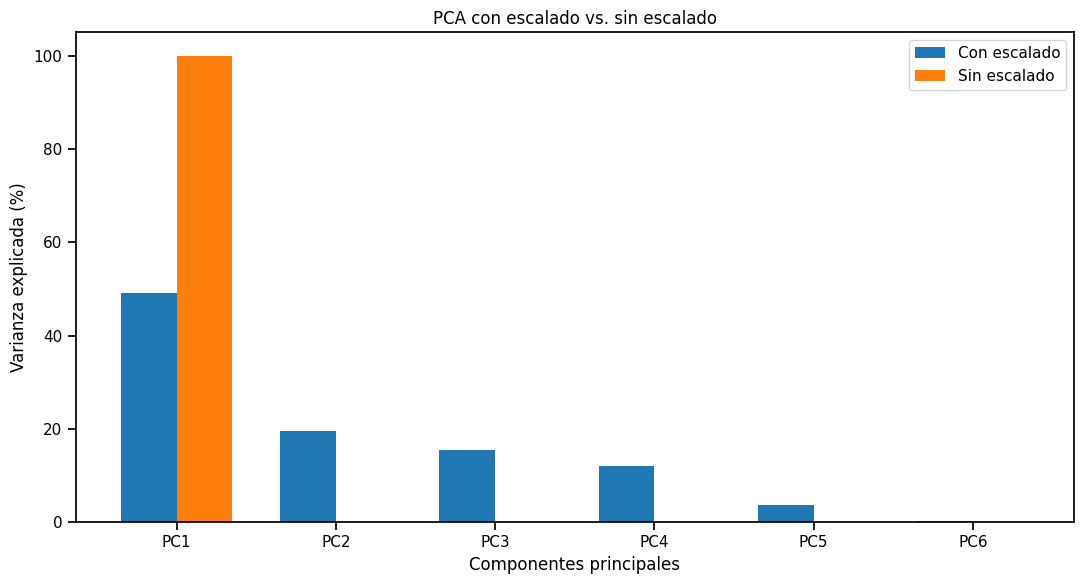

In [ ]:
x = np.arange(
    len(comparacion_varianza)
)

ancho = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - ancho / 2,
    comparacion_varianza["Con_escalado_%"],
    width=ancho,
    label="Con escalado"
)

plt.bar(
    x + ancho / 2,
    comparacion_varianza["Sin_escalado_%"],
    width=ancho,
    label="Sin escalado"
)

plt.xticks(
    x,
    comparacion_varianza["Componente"]
)

plt.title("PCA con escalado vs. sin escalado")
plt.xlabel("Componentes principales")
plt.ylabel("Varianza explicada (%)")

plt.legend()
plt.tight_layout()
plt.show()

## 18.1. K-Means sin escalado

Se utiliza el mismo número de clústeres para observar si las asignaciones cambian.

In [ ]:
X_pca_sin_escalar = componentes_sin_escalar[
    :,
    :n_componentes_80
]

kmeans_sin_escalar = KMeans(
    n_clusters=int(k_optimo),
    random_state=42,
    n_init=50
)

clusters_sin_escalar = (
    kmeans_sin_escalar.fit_predict(
        X_pca_sin_escalar
    )
)

comparacion_clusters = pd.crosstab(
    pd.Series(
        clusters,
        name="Cluster_con_escalado"
    ),
    pd.Series(
        clusters_sin_escalar,
        name="Cluster_sin_escalado"
    )
)

display(comparacion_clusters)

Cluster_sin_escalado,0,1,2,3,4
Cluster_con_escalado,,,,,
0,1,0,0,0,9
1,0,61,0,1,0
2,9,0,0,16,10
3,24,1,0,18,9
4,4,0,37,0,0


### Interpretación de los clústeres con y sin escalado

La tabla compara cómo cambian las asignaciones de las citas cuando K-Means se aplica con las variables escaladas y sin escalarlas.

Los resultados muestran que algunos grupos se conservan bastante bien, mientras que otros cambian de forma importante:

- **Clúster 0 con escalado:** de sus 10 citas, **9 pasan al clúster 4** sin escalado y solo 1 permanece en el clúster 0.
- **Clúster 1 con escalado:** es el grupo más estable. **61 de sus 62 citas** permanecen juntas en el clúster 1 sin escalado.
- **Clúster 2 con escalado:** presenta una redistribución importante: 9 citas pasan al clúster 0, 16 al clúster 3 y 10 al clúster 4.
- **Clúster 3 con escalado:** también cambia considerablemente. Sus 52 citas se reparten principalmente entre los clústeres 0, 3 y 4.
- **Clúster 4 con escalado:** se conserva casi por completo, ya que **37 de sus 41 citas** pasan juntas al clúster 2 sin escalado y solo 4 se ubican en el clúster 0.

### Conclusión

La comparación demuestra que **el escalado modifica de forma importante la segmentación obtenida por K-Means**.

Aunque algunos grupos permanecen relativamente estables, como los clústeres 1 y 4, otros presentan una redistribución considerable cuando se trabaja con las variables en sus escalas originales.

Esto confirma que, sin escalado, las variables con valores numéricos más grandes pueden dominar las distancias utilizadas por K-Means y cambiar la composición de los grupos.

Por esta razón, para este taller se consideran como resultados principales los clústeres obtenidos **después de escalar las variables**.



# 19. Respuestas a las preguntas del taller

## Pregunta 1. ¿Cuántas componentes principales explican al menos el 80 % de la varianza?

In [ ]:
print(
    f"Se necesitan {n_componentes_80} componentes principales."
)

print(
    "Varianza acumulada:",
    f"{varianza_acumulada[n_componentes_80 - 1] * 100:.2f}%"
)

Se necesitan 3 componentes principales.
Varianza acumulada: 84.17%


## Pregunta 2. ¿Qué variables dominan PC1 y PC2?

In [ ]:
print("PC1:")
display(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .to_frame("peso_absoluto")
    .round(3)
)

print("\nPC2:")
display(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .to_frame("peso_absoluto")
    .round(3)
)

PC1:


,peso_absoluto
duracion_min,0.5640
costo_cita,0.5630
satisfaccion,0.5200
dias_tratamiento,0.2660
dosis_mg,0.1130
edad,0.1040



PC2:


,peso_absoluto
dosis_mg,0.7190
dias_tratamiento,0.4790
edad,0.4680
satisfaccion,0.1850
duracion_min,0.0050
costo_cita,0.0020


## Pregunta 3. ¿Cuál es el número óptimo de clústeres según el codo?

In [ ]:
print(
    f"El método del codo sugiere trabajar con {int(k_optimo)} clústeres."
)

El método del codo sugiere trabajar con 5 clústeres.


## Pregunta 4. Perfil promedio de cada clúster

In [ ]:
display(perfil_clusters)

,edad,duracion_min,costo_cita,satisfaccion,dosis_mg,dias_tratamiento
cluster_ml,,,,,,
0,41.1000,35.0000,"205,000.0000",5.0000,600.0000,90.0000
1,40.3100,53.6300,"312,741.9400",3.1500,146.0500,50.4800
2,53.0600,37.5700,"221,428.5700",4.2600,155.7100,37.1400
3,29.5800,35.4800,"210,384.6200",4.2100,107.5200,36.7300
4,36.6600,22.3200,"129,756.1000",5.0000,241.8200,7.1500


## Pregunta 5. ¿Qué especialidad predomina en cada clúster?

In [ ]:
display(especialidad_predominante)

,especialidad_predominante
cluster_ml,
0,Ginecología
1,Neurología
2,Ortopedia
3,Dermatología
4,Pediatría


## Pregunta 6. ¿Cómo cambian los resultados si no se escalan las variables?

La evidencia se encuentra en:

- La gráfica de varianza explicada con y sin escalado.
- La tabla de comparación de las asignaciones de K-Means.

Si una variable con valores muy grandes domina el análisis sin escalado, los resultados dejan de representar de forma equilibrada las seis variables clínicas.

## Pregunta 7. ¿Qué acciones concretas propondrías para la clínica?

In [ ]:
cluster_mayor_duracion = perfil_clusters["duracion_min"].idxmax()
cluster_mayor_costo = perfil_clusters["costo_cita"].idxmax()
cluster_menor_satisfaccion = perfil_clusters["satisfaccion"].idxmin()
cluster_mayor_tratamiento = perfil_clusters["dias_tratamiento"].idxmax()

print(
    f"• Clúster {cluster_mayor_duracion}: revisar agenda, tiempos de consulta "
    "y disponibilidad de salas por presentar la mayor duración promedio."
)

print(
    f"• Clúster {cluster_mayor_costo}: revisar estructura de costos y tarifas "
    "por presentar el mayor costo promedio de las citas."
)

print(
    f"• Clúster {cluster_menor_satisfaccion}: priorizar acciones de experiencia "
    "del paciente y seguimiento a la satisfacción."
)

print(
    f"• Clúster {cluster_mayor_tratamiento}: fortalecer el seguimiento de los "
    "tratamientos de mayor duración."
)

• Clúster 1: revisar agenda, tiempos de consulta y disponibilidad de salas por presentar la mayor duración promedio.
• Clúster 1: revisar estructura de costos y tarifas por presentar el mayor costo promedio de las citas.
• Clúster 1: priorizar acciones de experiencia del paciente y seguimiento a la satisfacción.
• Clúster 0: fortalecer el seguimiento de los tratamientos de mayor duración.


## Pregunta 8. ¿Qué riesgos éticos implicaría usar estos clústeres para decisiones clínicas?

Los principales riesgos son:

- Tratar los clústeres como diagnósticos cuando únicamente representan grupos estadísticos.
- Tomar decisiones automáticas que puedan afectar la atención de un paciente.
- Reproducir sesgos existentes en los datos.
- Utilizar información clínica sin controles adecuados de privacidad.
- Generalizar resultados obtenidos con una muestra limitada.

Los clústeres deben utilizarse como apoyo para el análisis y la gestión, no como reemplazo del criterio médico.

# 20. Resultados finales del modelo

Se dejan disponibles las columnas solicitadas por el taller:

- `cluster_ml`
- `pc1`
- `pc2`

In [ ]:
resultado_final = df_resultados[
    [
        "id_cita",
        "cluster_ml",
        "pc1",
        "pc2"
    ]
].copy()

display(resultado_final.head())

,id_cita,cluster_ml,pc1,pc2
0,1,3,-0.1641,-0.6044
1,2,2,-1.0361,0.6303
2,3,4,-2.0455,-1.1973
3,4,1,2.4780,-0.5002
4,5,4,-2.7038,-1.8522


## 20.1. Exportar los resultados

El usuario de la base de datos tiene únicamente permisos de consulta, por lo que no puede insertar ni modificar registros.

Por esta razón, los resultados se exportan a CSV. Quedan listos para ser cargados posteriormente por un usuario que sí tenga permisos de escritura.

In [ ]:
resultado_final.to_csv(
    "resultados_pca_kmeans_clinica.csv",
    index=False
)

print(
    "Archivo creado: resultados_pca_kmeans_clinica.csv"
)

Archivo creado: resultados_pca_kmeans_clinica.csv


# 21. Conclusión

El taller permitió conectar Python con una base de datos MySQL, integrar información mediante `JOIN`, realizar análisis exploratorio, escalar las variables, reducir la dimensionalidad con PCA y segmentar las citas médicas mediante K-Means.

La interpretación final se realiza con las variables originales, permitiendo identificar perfiles de citas y posibles acciones para la gestión de la clínica.